In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import sys
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

base = r"D:\exoALMA_disk_data"
panel_width = {"LkCa_15": 6.12, "SY_Cha": 4.99, "AA_Tau": 4.24, "J1615": 4.76, "J1842": 3.84}
points = {
    "LkCa_15": (0.6685520361990951, 0.44784580498866217),
    "SY_Cha":  (0.5963718820861679, 0.4368600682593856),
    "AA_Tau":  (0.5607798165137615, 0.5459770114942528),
    "J1615":   (0.5199089874857793, 0.2753128555176337),
    "J1842":   (0.5600907029478458, 0.6011299435028249),
}

# panel coords: (0,0) = lower-left (RA=+W/2, DEC=-W/2), (W,W) = upper-right (RA=-W/2, DEC=+W/2)
# X = W/2 - RA, Y = DEC + W/2, with RA/DEC measured from the disk centre (dx, dy)
for name, W in panel_width.items():
    d = diskdict.disk[name]
    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust-0.5.image.fits")
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    RAo  = 3600 * hd["CDELT1"] * (np.arange(hd["NAXIS1"]) - (hd["CRPIX1"] - 1)) - d["dx"]
    DECo = 3600 * hd["CDELT2"] * (np.arange(hd["NAXIS2"]) - (hd["CRPIX2"] - 1)) - d["dy"]
    extent = [W / 2 - RAo[0], W / 2 - RAo[-1], DECo[0] + W / 2, DECo[-1] + W / 2]

    xf, yf = points[name]
    X, Y = xf * W, yf * W
    print(f"{name}: X,Y = ({X:.3f}, {Y:.3f}) arcsec  ->  RA,DEC = ({W / 2 - X:.3f}, {Y - W / 2:.3f}) arcsec")

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    fig.colorbar(im, ax=ax, fraction=0.046, label="mJy/beam")
    ax.plot(X, Y, marker="+", color="cyan", markersize=15, markeredgewidth=2)
    ax.set_title(f"{name.replace('_', ' ')} (W = {W} arcsec)")
    ax.set_xlabel("X (arcsec, from lower-left)")
    ax.set_ylabel("Y (arcsec, from lower-left)")
    ax.set_xlim(0, W)
    ax.set_ylim(0, W)
    plt.show()

AA_Tau: xf,yf=(0.561,0.546) -> RA,DEC=(-0.258, 0.195) arcsec -> r=0.323 arcsec (43.6 au), az=142.9 deg


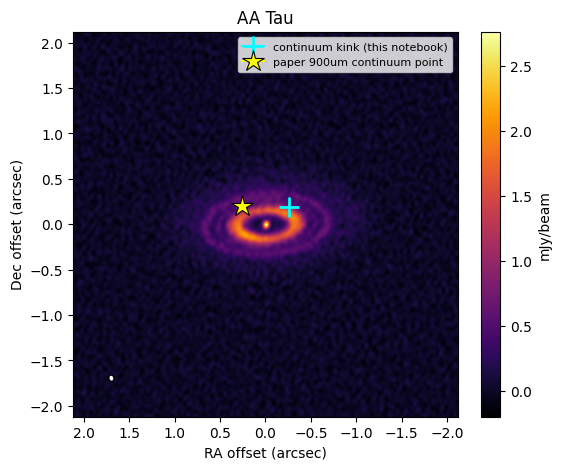

SY_Cha: xf,yf=(0.596,0.437) -> RA,DEC=(-0.481, -0.315) arcsec -> r=0.575 arcsec (104.6 au), az=-146.8 deg


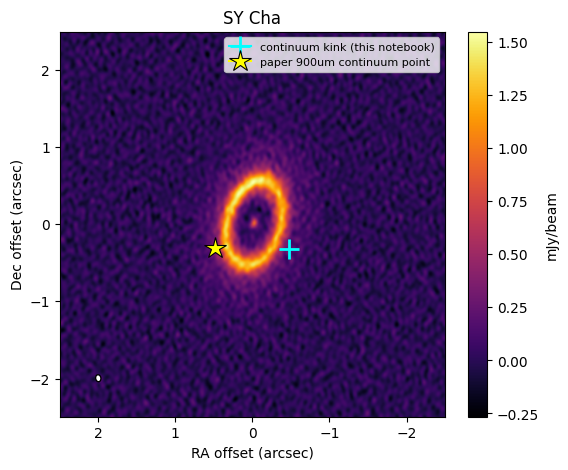

J1615: xf,yf=(0.520,0.275) -> RA,DEC=(-0.095, -1.070) arcsec -> r=1.074 arcsec (167.5 au), az=-95.1 deg


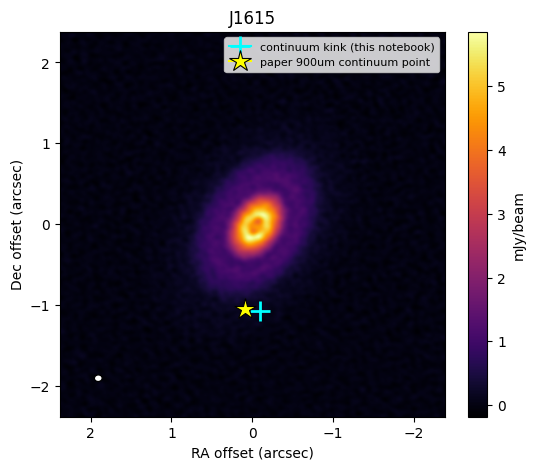

J1842: xf,yf=(0.560,0.601) -> RA,DEC=(-0.231, 0.388) arcsec -> r=0.452 arcsec (68.2 au), az=120.7 deg


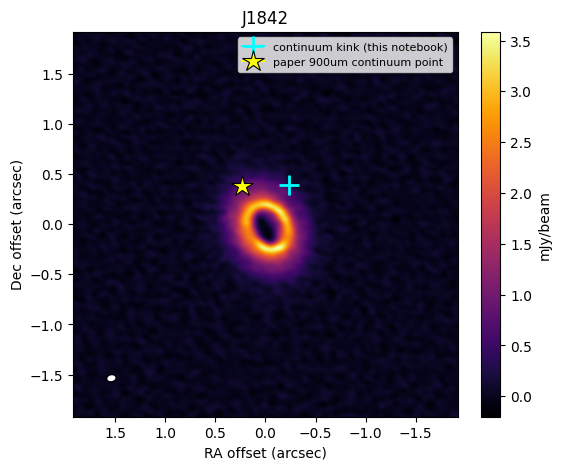

LkCa_15: xf,yf=(0.669,0.448) -> RA,DEC=(-1.032, -0.319) arcsec -> r=1.080 arcsec (168.4 au), az=-162.8 deg


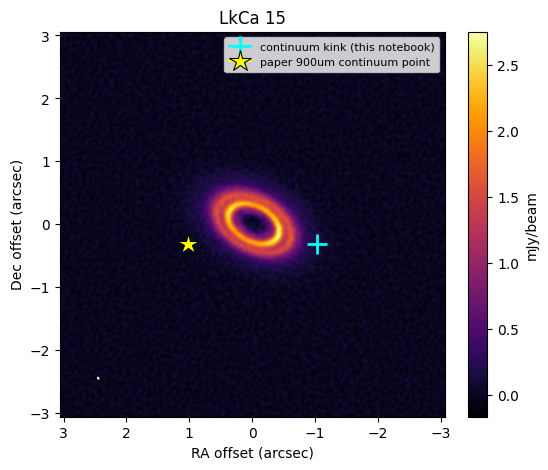

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.io import fits
import sys
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

base = r"D:\exoALMA_disk_data"
disks = ["AA_Tau", "SY_Cha", "J1615", "J1842", "LkCa_15"]

# kink-candidate positions, normalized (0-1) coords within the box each was
# picked from: (0,0) = bottom-left corner (RA=+half_width, DEC=-half_width),
# (1,1) = top-right corner (RA=-half_width, DEC=+half_width). xf/yf themselves
# are unaffected by panel angular scale -- only the RA/DEC conversion below
# depends on panel_width (each disk's own corrected full angular width).
points = {
    "LkCa_15": (0.6685520361990951, 0.44784580498866217),
    "SY_Cha":  (0.5963718820861679, 0.4368600682593856),
    "AA_Tau":  (0.5607798165137615, 0.5459770114942528),
    "J1615":   (0.5199089874857793, 0.2753128555176337),
    "J1842":   (0.5600907029478458, 0.6011299435028249),
}

# comparison point from a separate paper figure's row-4 (900um continuum) panel
# -- NOT SPHERE (that panel is row 5, not used here) -- so this is the same
# continuum tracer as our own image, just a different figure/reduction. x/y
# are on-sky RA/DEC offsets (arcsec) from the star, digitized assuming the
# panel's angular width equalled paper_cont_old_width. That assumed width was
# since corrected (panel_width) -- both x/y and the scale bar used to read
# them off scale together with panel width, so we rescale by
# new_width/old_width rather than re-digitizing from scratch. The corrected
# width also applies to our own kink point above -- same box-width correction.
paper_cont_xy_raw = {
    "LkCa_15": dict(x=1.84, y=-0.56),
    "SY_Cha":  dict(x=0.65, y=-0.42),
    "AA_Tau":  dict(x=0.36, y=0.28),
    "J1615":   dict(x=0.14, y=-1.55),
    "J1842":   dict(x=0.30, y=0.50),
}
paper_cont_old_width = {"LkCa_15": 11.00, "SY_Cha": 6.80, "AA_Tau": 6.00, "J1615": 7.00, "J1842": 5.00}
panel_width = {"LkCa_15": 6.12, "SY_Cha": 4.99, "AA_Tau": 4.24, "J1615": 4.76, "J1842": 3.84}
paper_cont_xy = {
    name: dict(x=s["x"] * panel_width[name] / paper_cont_old_width[name],
               y=s["y"] * panel_width[name] / paper_cont_old_width[name])
    for name, s in paper_cont_xy_raw.items()
}

results = []
for name in disks:
    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust-0.5.image.fits")
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo  = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0], RAo[-1], DECo[0], DECo[-1]]
    bmaj, bmin, bpa = 3600 * hd["BMAJ"], 3600 * hd["BMIN"], hd["BPA"]

    zoom = panel_width[name] / 2   # this disk's own corrected box half-width
    distance = diskdict.disk[name]["distance"]

    xf, yf = points[name]
    RA_pt  = panel_width[name] * (0.5 - xf)
    DEC_pt = panel_width[name] * (yf - 0.5)
    r_pt   = np.hypot(RA_pt, DEC_pt)
    r_au   = r_pt * distance
    az_pt  = np.degrees(np.arctan2(DEC_pt, RA_pt))
    print(f"{name}: xf,yf=({xf:.3f},{yf:.3f}) -> RA,DEC=({RA_pt:.3f}, {DEC_pt:.3f}) arcsec "
          f"-> r={r_pt:.3f} arcsec ({r_au:.1f} au), az={az_pt:.1f} deg")
    results.append({"disk": name, "xf": xf, "yf": yf, "RA (arcsec)": RA_pt,
                     "DEC (arcsec)": DEC_pt, "r (arcsec)": r_pt, "r (au)": r_au,
                     "az (deg)": az_pt})

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    fig.colorbar(im, ax=ax, fraction=0.046, label="mJy/beam")
    ax.plot(RA_pt, DEC_pt, marker="+", color="cyan", markersize=15, markeredgewidth=2,
            label="continuum kink (this notebook)")

    s = paper_cont_xy[name]
    ax.plot(s["x"], s["y"], marker="*", color="yellow", markersize=16, markeredgecolor="black",
            markeredgewidth=0.8, label="paper 900um continuum point")

    beam_x, beam_y = 0.8 * zoom, -0.8 * zoom   # lower-left corner
    ax.add_patch(Ellipse((beam_x, beam_y), bmin, bmaj, angle=bpa,
                          facecolor="white", edgecolor="black"))

    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("RA offset (arcsec)")
    ax.set_ylabel("Dec offset (arcsec)")
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.legend(fontsize=8, loc="upper right")
    plt.show()

In [2]:
import pandas as pd

pd.DataFrame(results)

,disk,xf,yf,RA (arcsec),DEC (arcsec),r (arcsec),r (au),az (deg)
0,AA_Tau,0.560780,0.545977,-0.257706,0.194943,0.323133,43.623008,142.894245
1,SY_Cha,0.596372,0.436860,-0.480896,-0.315068,0.574916,104.634754,-146.768400
2,J1615,0.519909,0.275313,-0.094767,-1.069511,1.073701,167.497376,-95.063617
3,J1842,0.560091,0.601130,-0.230748,0.388339,0.451721,68.209885,120.718484
4,LkCa_15,0.668552,0.447846,-1.031538,-0.319184,1.079792,168.447484,-162.806631


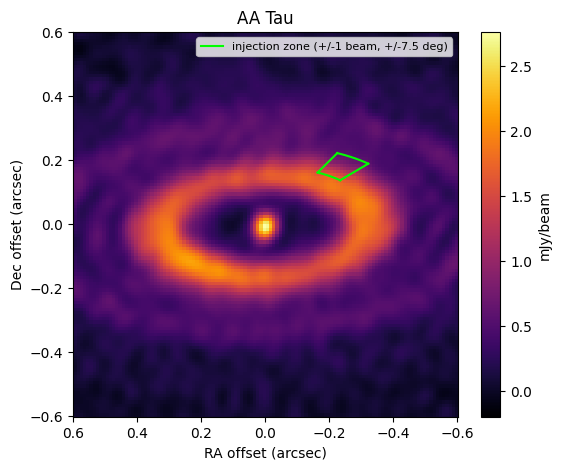

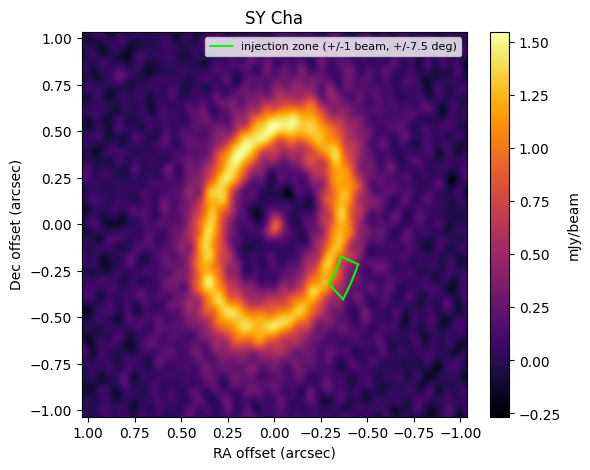

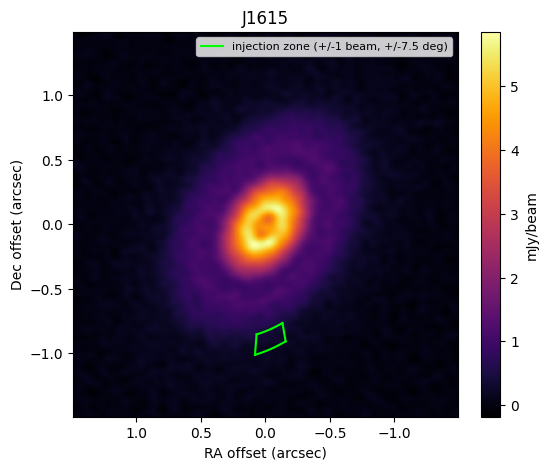

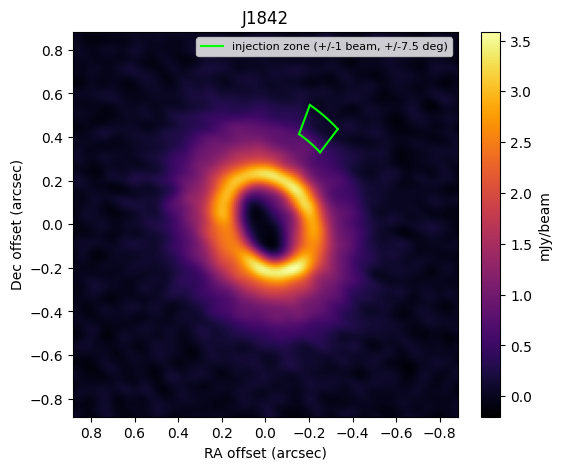

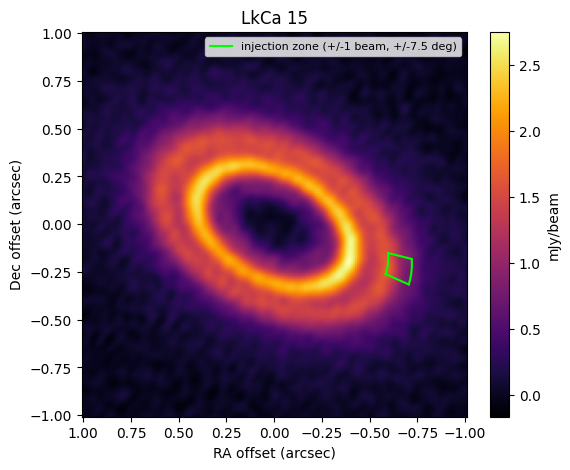

In [3]:
import sys
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

# disk-plane candidate position + beam FWHM used to build the kink injection-recovery
# pipeline (HPC_kink/{disk}_kink0/) -- injection zone = +/-1 beam radially, +/-7.5 deg wedge
kink_pipeline = {
    "AA_Tau":  dict(R=0.3994, AZ=-141.45, BEAM=0.0632),
    "SY_Cha":  dict(R=0.7167, AZ=14.58,   BEAM=0.0791),
    "J1615":   dict(R=1.0582, AZ=43.01,   BEAM=0.0900),
    "LkCa_15": dict(R=0.7093, AZ=-104.29, BEAM=0.0664),
    "J1842":   dict(R=0.5961, AZ=151.47,  BEAM=0.0831),
}
AZ_HALFWIDTH = 7.5   # deg

def polar_to_sky(r, az, PAr, inclr):
    x = r * np.sin(az) * np.sin(PAr) + r * np.cos(az) * np.cos(inclr) * np.cos(PAr)
    y = r * np.sin(az) * np.cos(PAr) - r * np.cos(az) * np.cos(inclr) * np.sin(PAr)
    return x, y

def wedge_outline(r_lo, r_hi, az_lo, az_hi, PAr, inclr, n=50):
    az_arc = np.radians(np.linspace(az_lo, az_hi, n))
    x1, y1 = polar_to_sky(r_lo, az_arc, PAr, inclr)
    x2, y2 = polar_to_sky(r_hi, az_arc, PAr, inclr)
    x3, y3 = polar_to_sky(np.array([r_lo, r_hi]), np.radians(az_lo), PAr, inclr)
    x4, y4 = polar_to_sky(np.array([r_lo, r_hi]), np.radians(az_hi), PAr, inclr)
    return x1, y1, x2, y2, x3, y3, x4, y4

for name in disks:
    p = kink_pipeline[name]
    R, AZ, BEAM = p["R"], p["AZ"], p["BEAM"]
    d = diskdict.disk[name]
    PAr, inclr = np.radians(d["PA"]), np.radians(d["incl"])

    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust-0.5.image.fits")
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo  = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - d["dx"], RAo[-1] - d["dx"], DECo[0] - d["dy"], DECo[-1] - d["dy"]]

    x1, y1, x2, y2, x3, y3, x4, y4 = wedge_outline(R - BEAM, R + BEAM, AZ - AZ_HALFWIDTH, AZ + AZ_HALFWIDTH, PAr, inclr)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    fig.colorbar(im, ax=ax, fraction=0.046, label="mJy/beam")
    ax.plot(x1, y1, color="lime", lw=1.5)
    ax.plot(x2, y2, color="lime", lw=1.5)
    ax.plot(x3, y3, color="lime", lw=1.5)
    ax.plot(x4, y4, color="lime", lw=1.5, label="injection zone (+/-1 beam, +/-7.5 deg)")
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("RA offset (arcsec)")
    ax.set_ylabel("Dec offset (arcsec)")
    zoom = 1.3 * (R + BEAM)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.legend(fontsize=8, loc="upper right")
    plt.show()

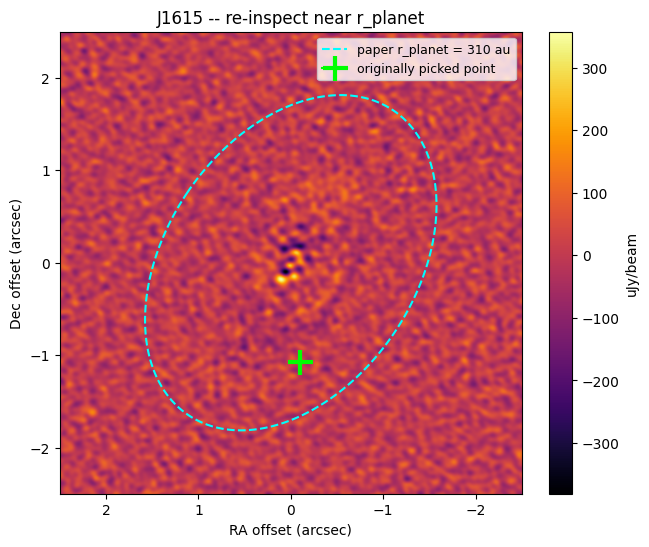

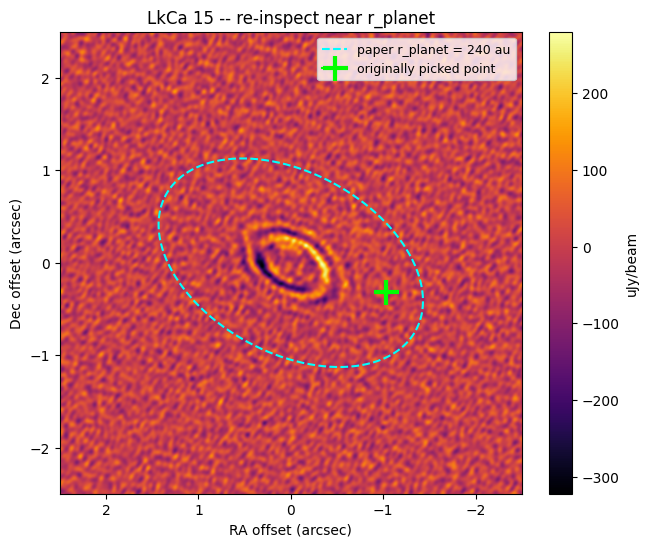

In [4]:
# Re-inspection: J1615 and LkCa_15 disagree badly with the phantom+mcfost
# paper's CO-kinematic r_planet (310 au and 240 au) vs where we picked the
# continuum kink. Widen the view and mark r_planet (as a projected ellipse,
# since it's a disk-plane radius) so we can actually look. RA_pt/DEC_pt here
# use each disk's own corrected panel_width half-width (not a fixed box).

paper_r_planet_au = {"J1615": 310, "LkCa_15": 240}
WIDE_BOX = 2.5   # arcsec, wide enough to comfortably show r_planet with margin

for name in ["J1615", "LkCa_15"]:
    d = diskdict.disk[name]
    PAr, inclr = np.radians(d["PA"]), np.radians(d["incl"])
    r_planet_arcsec = paper_r_planet_au[name] / d["distance"]

    hdu = fits.open(f"{base}/{name}/images_frank_residuals_different_robust/{name}_continuum_resid_robust-0.5.image.fits")
    img = 1e6 * np.squeeze(hdu[0].data)   # uJy/beam
    hd = hdu[0].header
    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo  = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - d["dx"], RAo[-1] - d["dx"], DECo[0] - d["dy"], DECo[-1] - d["dy"]]

    # ring at r_planet, projected to the sky plane (full azimuth)
    az_trace = np.radians(np.linspace(-180, 180, 361))
    x_ring = r_planet_arcsec * np.sin(az_trace) * np.sin(PAr) +              r_planet_arcsec * np.cos(az_trace) * np.cos(inclr) * np.cos(PAr)
    y_ring = r_planet_arcsec * np.sin(az_trace) * np.cos(PAr) -              r_planet_arcsec * np.cos(az_trace) * np.cos(inclr) * np.sin(PAr)

    zoom = panel_width[name] / 2
    xf, yf = points[name]
    RA_pt  = zoom - 2 * zoom * xf
    DEC_pt = -zoom + 2 * zoom * yf

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    fig.colorbar(im, ax=ax, fraction=0.046, label="uJy/beam")
    ax.plot(x_ring, y_ring, color="cyan", ls="--", lw=1.5,
            label=f"paper r_planet = {paper_r_planet_au[name]} au")
    ax.plot(RA_pt, DEC_pt, marker="+", color="lime", markersize=18, markeredgewidth=3,
            label="originally picked point")
    ax.set_title(f"{name.replace('_', ' ')} -- re-inspect near r_planet")
    ax.set_xlabel("RA offset (arcsec)")
    ax.set_ylabel("Dec offset (arcsec)")
    ax.set_xlim(WIDE_BOX, -WIDE_BOX)
    ax.set_ylim(-WIDE_BOX, WIDE_BOX)
    ax.legend(fontsize=9, loc="upper right")
    plt.show()

In [5]:
# compare our kink-pipeline (r, theta) against Table 2 of the phantom+mcfost
# paper (r_planet) and against the same paper's own 900um continuum point
# (row-4 panel, NOT SPHERE row-5 -- same tracer as our own image, just a
# different figure/reduction) -- same 5 disks. Our r/theta are the disk-plane
# (R, AZ) values already used to build the HPC_kink injection zones above;
# converted to au via each disk's own distance for direct comparison.
# paper_cont_xy here uses the corrected panel width (panel_width, rescaled
# from the original digitization -- see cell above).
paper_r_planet_au = {"AA_Tau": 80, "J1615": 310, "J1842": 105, "LkCa_15": 240, "SY_Cha": 140}

rows = []
for name in disks:
    p = kink_pipeline[name]
    distance = diskdict.disk[name]["distance"]
    s = paper_cont_xy[name]
    r_cont_arcsec = np.hypot(s["x"], s["y"])
    theta_cont_deg = np.degrees(np.arctan2(s["y"], s["x"]))
    rows.append({
        "disk": name.replace("_", " "),
        "our r (au)": round(p["R"] * distance, 1),
        "our theta (deg)": round(p["AZ"], 1),
        "paper r_planet (au)": paper_r_planet_au[name],
        "paper cont. r (au)": round(r_cont_arcsec * distance, 1),
        "paper cont. theta (deg)": round(theta_cont_deg, 1),
    })

kink_vs_paper = pd.DataFrame(rows)
kink_vs_paper

,disk,our r (au),our theta (deg),paper r_planet (au),paper cont. r (au),paper cont. theta (deg)
0,AA Tau,53.9,-141.4,80,43.5,37.9
1,SY Cha,130.4,14.6,140,103.4,-32.9
2,J1615,165.1,43.0,310,165.1,-84.8
3,J1842,90.0,151.5,105,67.6,59.0
4,LkCa 15,110.7,-104.3,240,166.9,-16.9


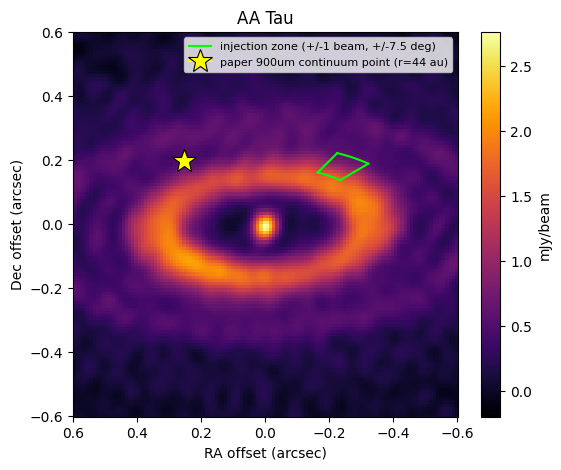

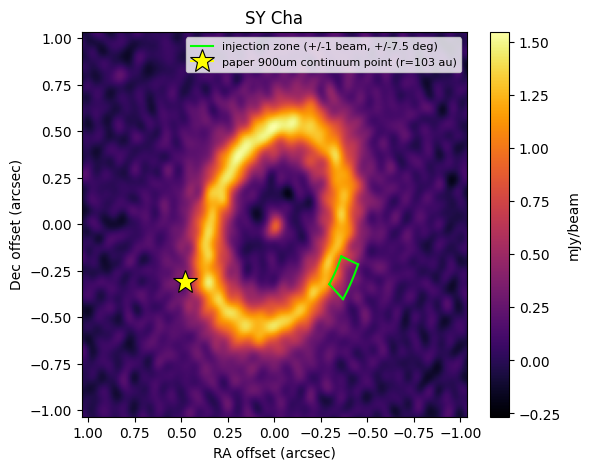

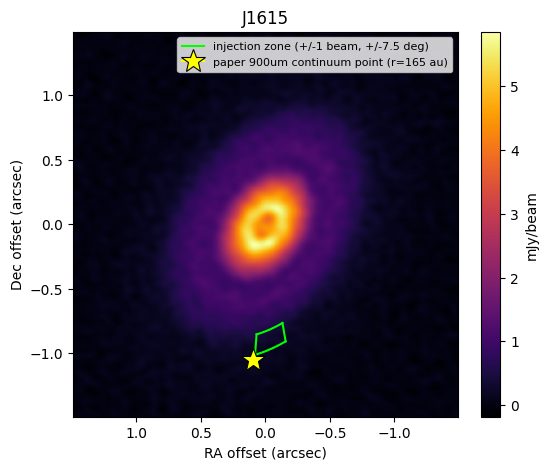

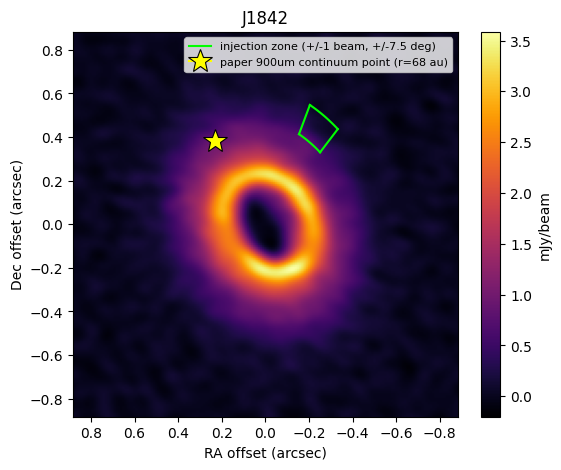

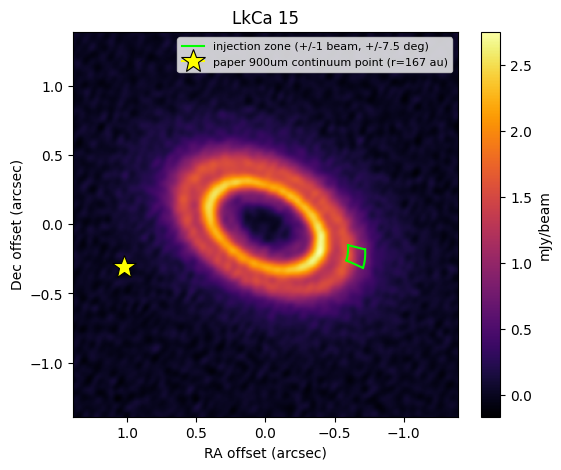

In [6]:
# same per-disk zoom-in as the injection-zone plot above, as a NEW cell (that
# one is left untouched) -- adds the paper's own 900um continuum point
# (paper_cont_xy, corrected panel width -- see cell above) as a comparison
# marker. Zoom widened per-disk to fit whichever of the injection zone /
# paper point sits further out.
for name in disks:
    p = kink_pipeline[name]
    R, AZ, BEAM = p["R"], p["AZ"], p["BEAM"]
    d = diskdict.disk[name]
    PAr, inclr = np.radians(d["PA"]), np.radians(d["incl"])

    s = paper_cont_xy[name]
    r_cont = np.hypot(s["x"], s["y"])

    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust-0.5.image.fits")
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    nx, ny = hd["NAXIS1"], hd["NAXIS2"]
    RAo  = 3600 * hd["CDELT1"] * (np.arange(nx) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(ny) - (hd["CRPIX2"] - 1))
    extent = [RAo[0] - d["dx"], RAo[-1] - d["dx"], DECo[0] - d["dy"], DECo[-1] - d["dy"]]

    x1, y1, x2, y2, x3, y3, x4, y4 = wedge_outline(R - BEAM, R + BEAM, AZ - AZ_HALFWIDTH, AZ + AZ_HALFWIDTH, PAr, inclr)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=extent)
    fig.colorbar(im, ax=ax, fraction=0.046, label="mJy/beam")
    ax.plot(x1, y1, color="lime", lw=1.5)
    ax.plot(x2, y2, color="lime", lw=1.5)
    ax.plot(x3, y3, color="lime", lw=1.5)
    ax.plot(x4, y4, color="lime", lw=1.5, label="injection zone (+/-1 beam, +/-7.5 deg)")
    ax.plot(s["x"], s["y"], marker="*", color="yellow", markersize=18, markeredgecolor="black",
             markeredgewidth=0.8, label=f"paper 900um continuum point (r={r_cont * d['distance']:.0f} au)")
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("RA offset (arcsec)")
    ax.set_ylabel("Dec offset (arcsec)")
    zoom = 1.3 * max(R + BEAM, r_cont)
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    ax.legend(fontsize=8, loc="upper right")
    plt.show()